# 01. RC Numerical Validation

본격적인 신경 인터페이스 모델을 구현하기 전에,
해석해를 알고 있는 간단한 RC 회로를 이용하여
미분방정식과 수치적분 구현을 검증한다.

RC charging equation은

\[
RC\frac{dV}{dt}=V_{\mathrm{in}}-V
\]

이며,

\[
\frac{dV}{dt}
=
\frac{V_{\mathrm{in}}-V}{RC}
\]

로 쓸 수 있다.

초기조건 \(V(0)=0\)에서 해석해는

\[
V(t)=V_{\mathrm{in}}
\left(1-e^{-t/(RC)}\right)
\]

이다.

본 예제에서는

\[
R=100\,\mathrm{k\Omega}, \qquad
C=10\,\mathrm{nF}
\]

를 사용한다.

이 값들은 **수치해석 구현 검증을 위한 예시값이며
실제 신경 전극의 측정값이 아니다.**

또한 RC 회로는 이후 사용할 신경 인터페이스 상태변수
\(h\)를 물리적으로 유도하기 위한 모델이 아니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R = 100_000.0
C = 10e-9
V_in = 1e-3

tau = R * C

print(f"Time constant = {tau * 1e3:.2f} ms")

Time constant = 1.00 ms


dt= 100.0 µs | max error= 19.201 µV
dt=  50.0 µs | max error=  9.394 µV
dt=  25.0 µs | max error=  4.647 µV


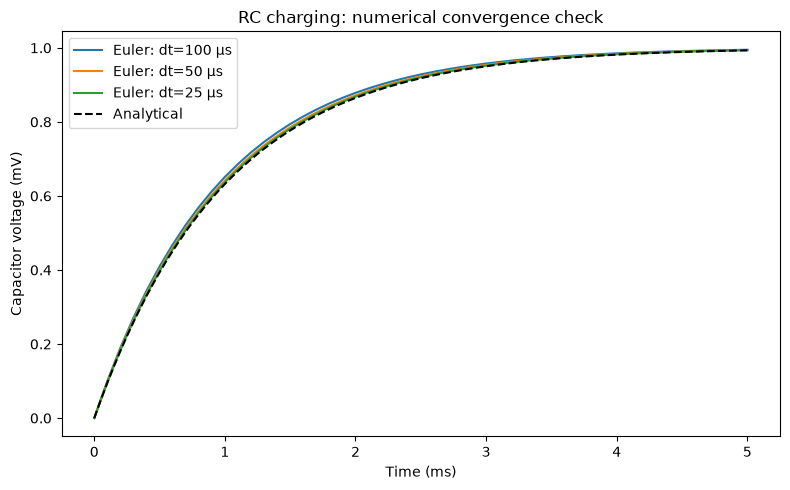

Time constant: 1.00 ms | time-step halving test passed


In [2]:
def rc_euler(dt, duration = 5 * tau):
    n_steps = int(round(duration / dt))
    t = np.arange(n_steps + 1) * dt

    # 초기조건 V(0) = 0
    v = np.zeros(n_steps + 1)

    for i in range(n_steps):

        # 현재 시점에서의 변화율
        dv_dt = (V_in - v[i]) / tau

        # Euler update
        v[i + 1] = v[i] + dt * dv_dt

    # Analytical solution
    exact = V_in * (1 - np.exp(-t / tau))

    return t, v, exact


steps = [
    tau / 10,
    tau / 20,
    tau / 40
]

errors = []

fig, ax = plt.subplots(figsize=(8, 5))

for dt in steps:

    t, v, exact = rc_euler(dt)

    error = np.max(np.abs(v - exact))
    errors.append(error)

    ax.plot(
        t * 1e3,
        v * 1e3,
        label=f"Euler: dt={dt * 1e6:.0f} µs"
    )

    print(
        f"dt={dt * 1e6:6.1f} µs | "
        f"max error={error * 1e6:7.3f} µV"
    )

# Analytical solution
ax.plot(
    t * 1e3,
    exact * 1e3,
    "k--",
    label="Analytical"
)

ax.set(
    xlabel="Time (ms)",
    ylabel="Capacitor voltage (mV)",
    title="RC charging: numerical convergence check"
)

ax.legend()

plt.tight_layout()
plt.show()

assert errors[2] < errors[1] < errors[0]

assert all(
    1.8 < errors[i] / errors[i + 1] < 2.2
    for i in range(len(errors) - 1)
)

print(
    f"Time constant: {tau * 1e3:.2f} ms | "
    "time-step halving test passed"
)
